In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [60]:
df = pd.read_csv(r'C:\Users\A\Desktop\DepositSense-ML\Dataset\bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [61]:
df.shape

(11162, 17)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [63]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,11162.0,NaN,NaN,NaN,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
job,11162,12,management,2566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,11162,3,married,6351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,11162,4,secondary,5476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,11162,2,no,10994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,11162.0,NaN,NaN,NaN,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
housing,11162,2,no,5881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,11162,2,no,9702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,11162,3,cellular,8042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,11162.0,NaN,NaN,NaN,15.658036,8.42074,1.0,8.0,15.0,22.0,31.0


In [66]:
df.nunique()

age            76
job            12
marital         3
education       4
default         2
balance      3805
housing         2
loan            2
contact         3
day            31
month          12
duration     1428
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

In [67]:
df.rename(columns={'housing':'housing_loan','loan':'personal_loan'},inplace=True)

In [70]:
numeric_features=[feature for feature in df.columns if df[feature].dtype!='str']
categorical_features=[feature for feature in df.columns if df[feature].dtype =='str']
print(f'In the dataset the numeric columns are {numeric_features}')
print()
print(f'In the dataset the categorical columns are {categorical_features}')

In the dataset the numeric columns are ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In the dataset the categorical columns are ['job', 'marital', 'education', 'default', 'housing_loan', 'personal_loan', 'contact', 'month', 'poutcome', 'deposit']


In [71]:
for i in range(len(df.columns)):
  feature=df.columns[i]
  if df[feature].dtype == 'str':
    print(f'In the "{feature}" they are {df[feature].nunique()} unique values they are :- {df[feature].unique()}')
    print()

In the "job" they are 12 unique values they are :- <StringArray>
[       'admin.',    'technician',      'services',    'management',
       'retired',   'blue-collar',    'unemployed',  'entrepreneur',
     'housemaid',       'unknown', 'self-employed',       'student']
Length: 12, dtype: str

In the "marital" they are 3 unique values they are :- <StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str

In the "education" they are 4 unique values they are :- <StringArray>
['secondary', 'tertiary', 'primary', 'unknown']
Length: 4, dtype: str

In the "default" they are 2 unique values they are :- <StringArray>
['no', 'yes']
Length: 2, dtype: str

In the "housing_loan" they are 2 unique values they are :- <StringArray>
['yes', 'no']
Length: 2, dtype: str

In the "personal_loan" they are 2 unique values they are :- <StringArray>
['no', 'yes']
Length: 2, dtype: str

In the "contact" they are 3 unique values they are :- <StringArray>
['unknown', 'cellular', 'telephone']
Length:

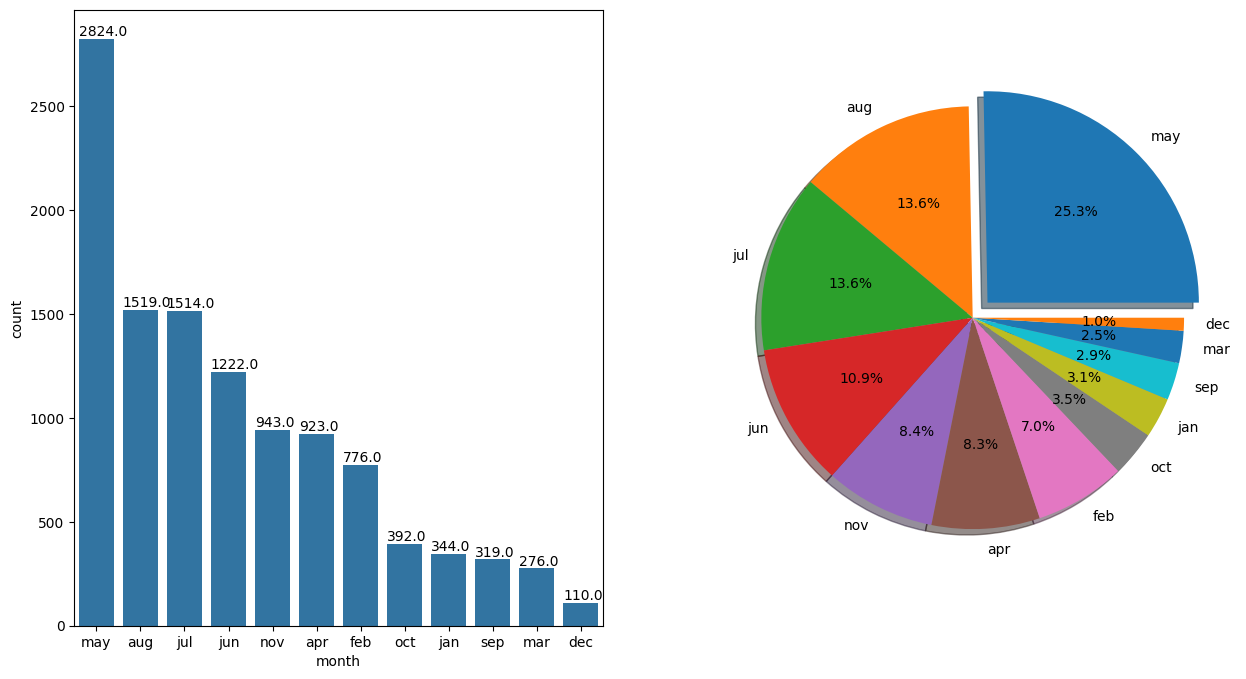

In [72]:
plt.figure(figsize=(15,8))
plt.subplot(121)
ax=sns.barplot(df['month'].value_counts())
for p in ax.patches:
  ax.annotate((p.get_height()),(p.get_x(),p.get_height()+15))
plt.subplot(122)
plt.pie(x=df['month'].value_counts(),labels=df['month'].value_counts().index,explode=[0.1,0,0,0,0,0,0,0,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()

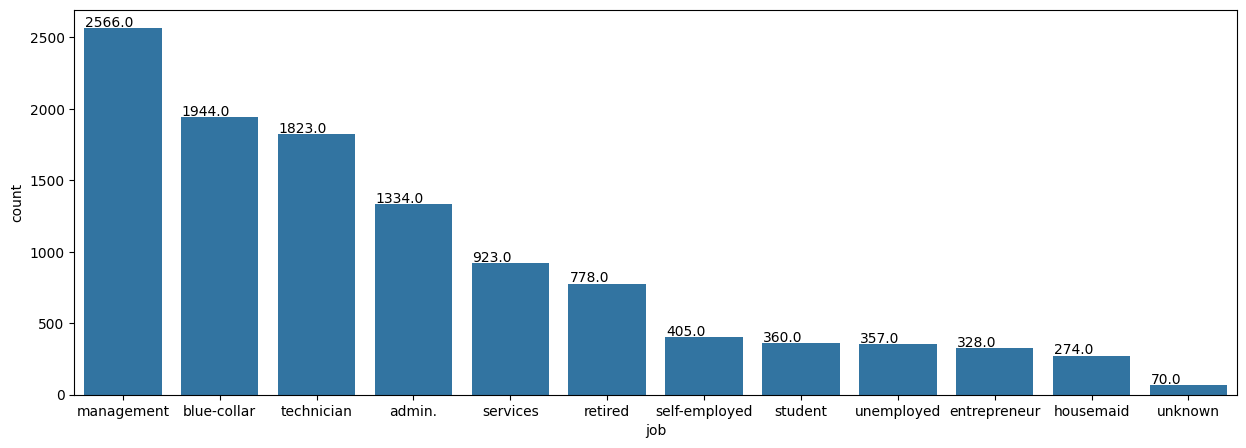

In [73]:
plt.figure(figsize=(15,5))
ax=sns.barplot(df['job'].value_counts())
for p in ax.patches:
  ax.annotate((p.get_height()),(p.get_x()+0.01,p.get_height()+10))
plt.show()

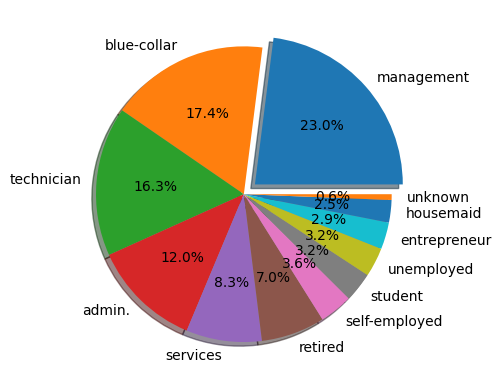

In [74]:
plt.pie(x=df['job'].value_counts(),labels=df['job'].value_counts().index,explode=[0.1,0,0,0,0,0,0,0,0,0,0,0],autopct="%1.1f%%",shadow=True)
plt.show()

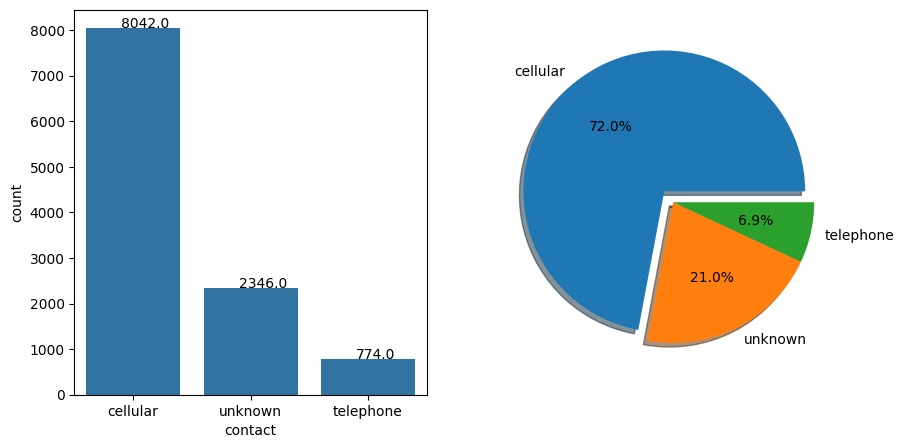

In [75]:
plt.figure(figsize=(10,5))
plt.subplot(121)
ax=sns.barplot(df['contact'].value_counts())
for p in ax.patches:
  ax.annotate((p.get_height()),(p.get_x()+0.3,p.get_height()+10))
plt.subplot(122)
plt.pie(x=df['contact'].value_counts(),labels=df['contact'].value_counts().index,explode=[0.1,0,0],autopct="%1.1f%%",shadow=True)
plt.show()

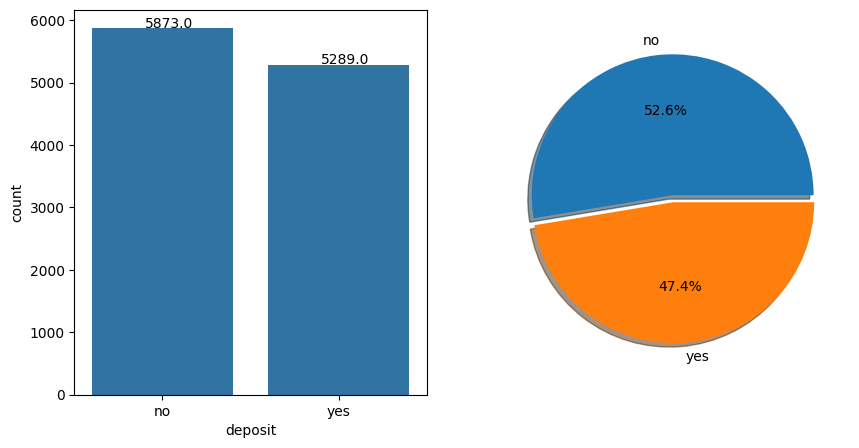

In [76]:
plt.figure(figsize=(10,5))
plt.subplot(121)
ax=sns.barplot(df['deposit'].value_counts())
for p in ax.patches:
  ax.annotate((p.get_height()),(p.get_x()+0.3,p.get_height()+10))
plt.subplot(122)
plt.pie(x=df['deposit'].value_counts(),labels=df['deposit'].value_counts().index,explode=[0.05,0],autopct="%1.1f%%",shadow=True)
plt.show()

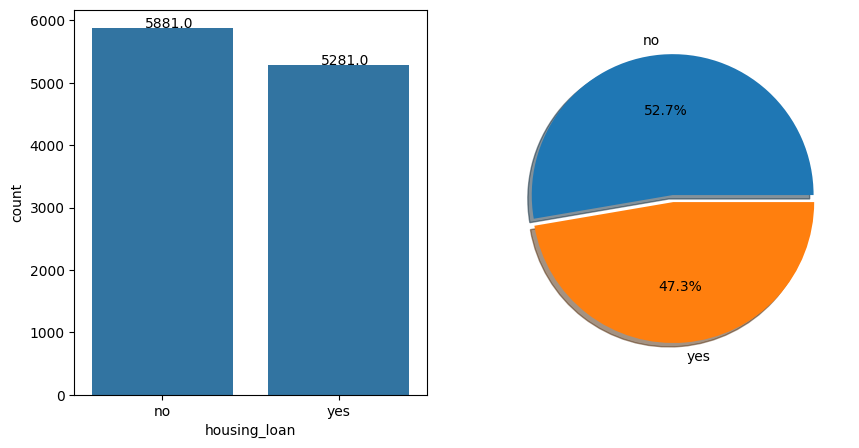

In [77]:
plt.figure(figsize=(10,5))
plt.subplot(121)
ax=sns.barplot(df['housing_loan'].value_counts())
for p in ax.patches:
  ax.annotate((p.get_height()),(p.get_x()+0.3,p.get_height()+10))
plt.subplot(122)
plt.pie(x=df['housing_loan'].value_counts(),labels=df['housing_loan'].value_counts().index,explode=[0.05,0],autopct="%1.1f%%",shadow=True)
plt.show()

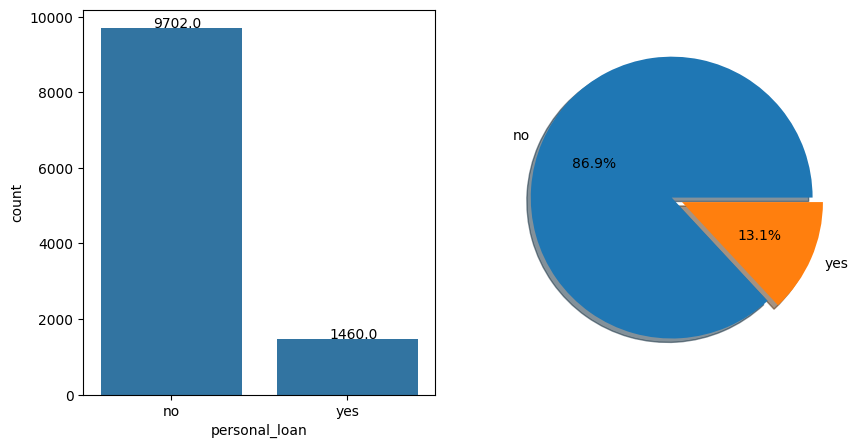

In [78]:
plt.figure(figsize=(10,5))
plt.subplot(121)
ax=sns.barplot(df['personal_loan'].value_counts())
for p in ax.patches:
  ax.annotate((p.get_height()),(p.get_x()+0.3,p.get_height()+10))
plt.subplot(122)
plt.pie(x=df['personal_loan'].value_counts(),explode=[0.08,0],autopct="%1.1f%%",labels=df['personal_loan'].value_counts().index,shadow=True)
plt.show()

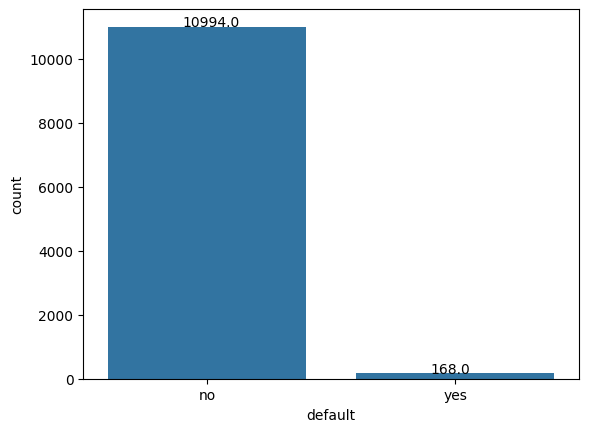

In [79]:
ax=sns.barplot(df['default'].value_counts())
for p in ax.patches:
  ax.annotate((p.get_height()),(p.get_x()+0.3,p.get_height()+10))
plt.show()

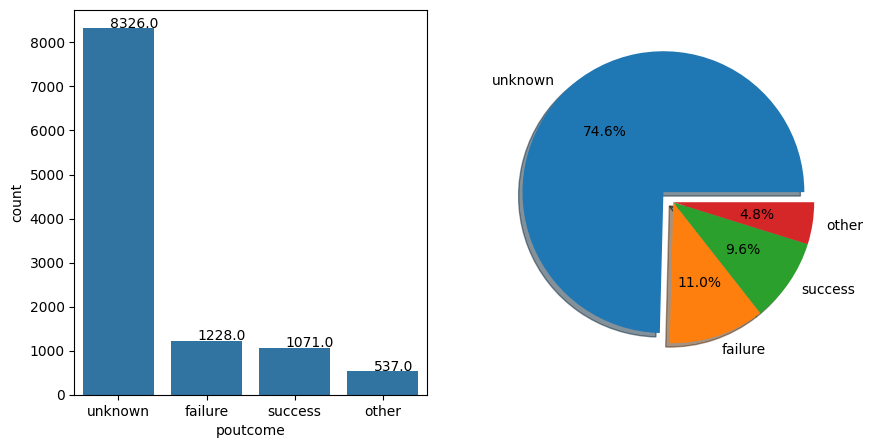

In [80]:
plt.figure(figsize=(10,5))
plt.subplot(121)
ax=sns.barplot(df['poutcome'].value_counts())
for p in ax.patches:
  ax.annotate((p.get_height()),(p.get_x()+0.3,p.get_height()+10))
plt.subplot(122)
plt.pie(x=df['poutcome'].value_counts(),labels=df['poutcome'].value_counts().index,explode=[0.1,0,0,0],autopct="%1.1f%%",shadow=True)
plt.show()

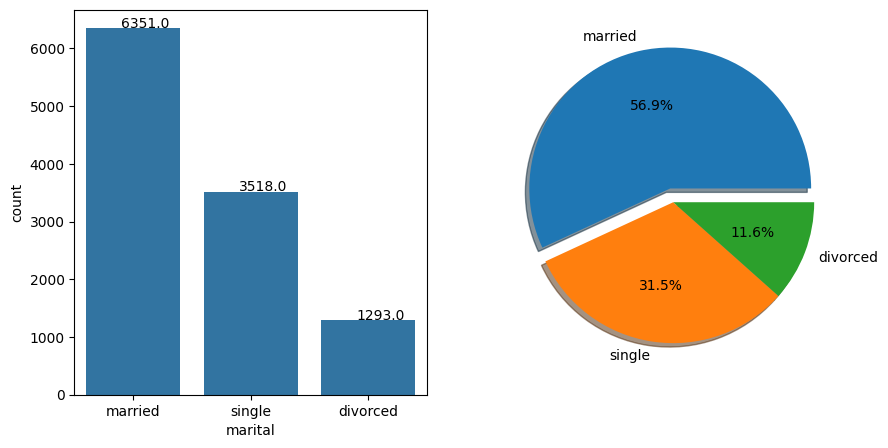

In [81]:
plt.figure(figsize=(10,5))
plt.subplot(121)
ax=sns.barplot(df['marital'].value_counts())
for p in ax.patches:
  ax.annotate((p.get_height()),(p.get_x()+0.3,p.get_height()+10))
plt.subplot(122)
plt.pie(x=df['marital'].value_counts(),labels=df['marital'].value_counts().index,explode=[0.1,0,0],autopct="%1.1f%%",shadow=True)
plt.show()

<Axes: xlabel='age', ylabel='Count'>

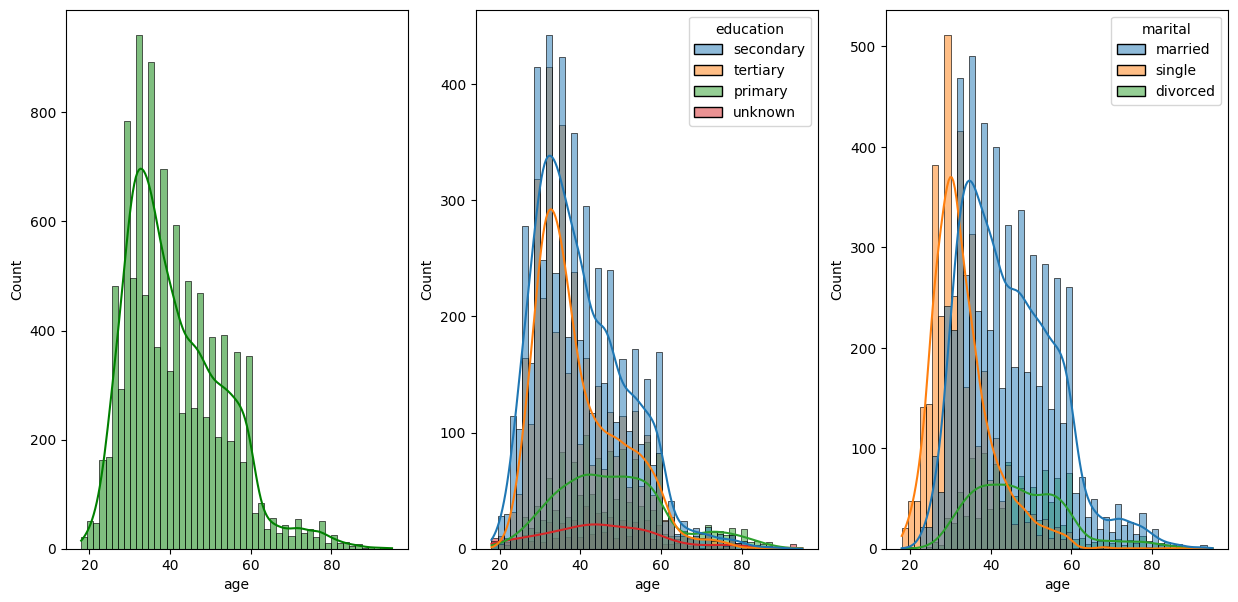

In [82]:
fig,ax=plt.subplots(1,3,figsize=(15,7))
plt.subplot(131)
sns.histplot(x=df['age'],kde=True,color="g")
plt.subplot(132)
sns.histplot(data=df,x='age',kde=True,hue='education')
plt.subplot(133)
sns.histplot(data=df,x='age',kde=True,hue='marital')

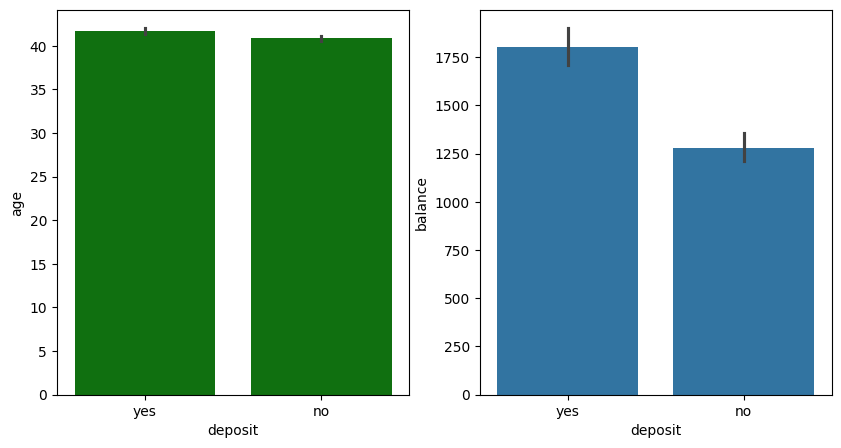

In [84]:
plt.figure(figsize=(10,5))
plt.subplot(121)
sns.barplot(x=df['deposit'],y=df['age'],color='g')
plt.subplot(122)
sns.barplot(x=df['deposit'],y=df['balance'])
plt.show()

In [85]:
df.corr(numeric_only=True)

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.112300,-0.000762,0.000189,-0.005278,0.002774,0.020169
balance,0.112300,1.000000,0.010467,0.022436,-0.013894,0.017411,0.030805
day,-0.000762,0.010467,1.000000,-0.018511,0.137007,-0.077232,-0.058981
duration,0.000189,0.022436,-0.018511,1.000000,-0.041557,-0.027392,-0.026716
campaign,-0.005278,-0.013894,0.137007,-0.041557,1.000000,-0.102726,-0.049699
pdays,0.002774,0.017411,-0.077232,-0.027392,-0.102726,1.000000,0.507272
previous,0.020169,0.030805,-0.058981,-0.026716,-0.049699,0.507272,1.000000


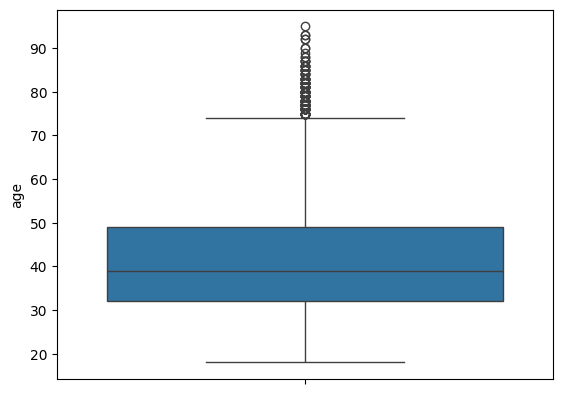

In [87]:
sns.boxplot(df['age'])
plt.show()

In [88]:
df[numeric_features].skew()

age         0.862780
balance     8.224619
day         0.111330
duration    2.143695
campaign    5.545578
pdays       2.449986
previous    7.335298
dtype: float64

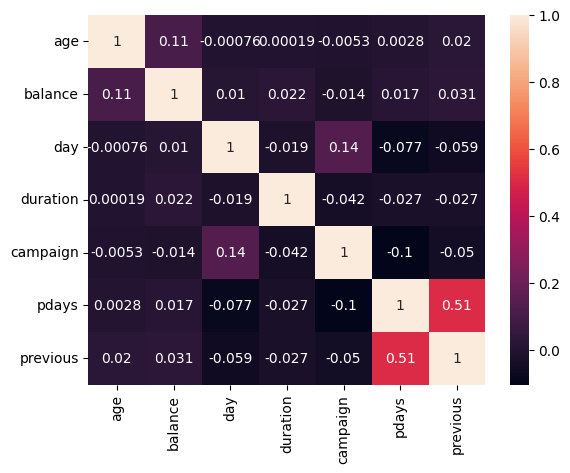

In [89]:
sns.heatmap(df[numeric_features].corr(),annot=True)
plt.show()

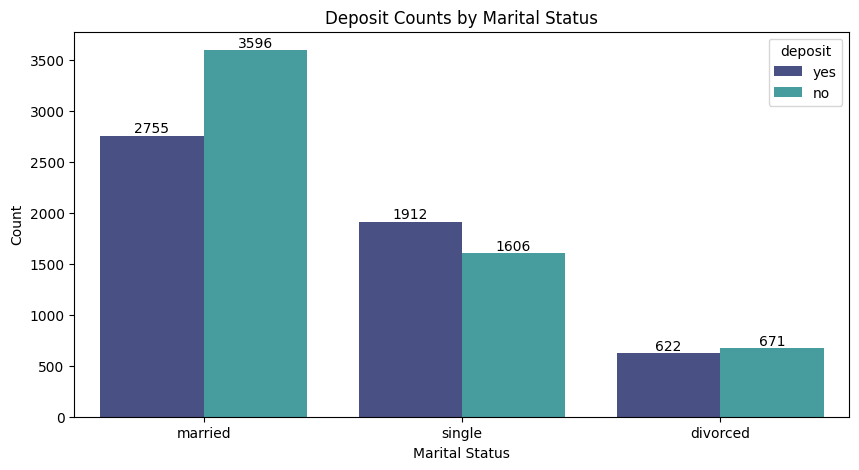

In [90]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='marital', hue='deposit', data=df, palette='mako')
plt.title('Deposit Counts by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.show()

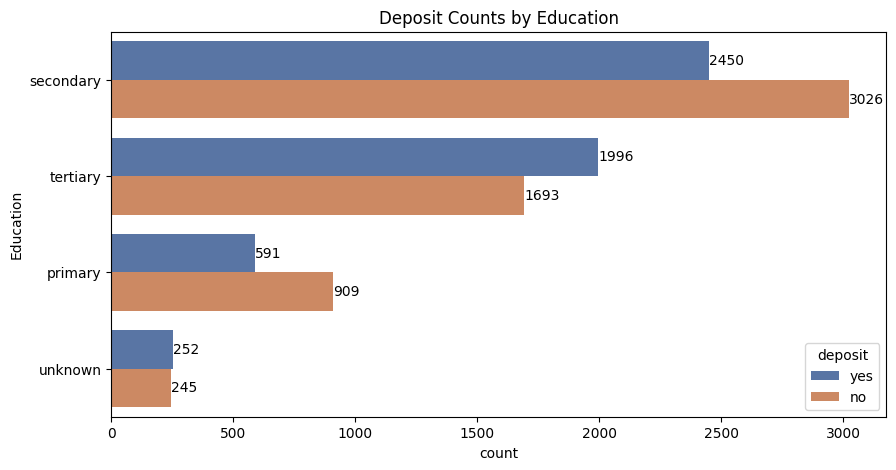

In [91]:
plt.figure(figsize=(10,5))
ax=sns.countplot(y=df['education'],hue=df['deposit'],palette='deep')
plt.title('Deposit Counts by Education')
plt.xlabel('count')
plt.ylabel('Education')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.show()

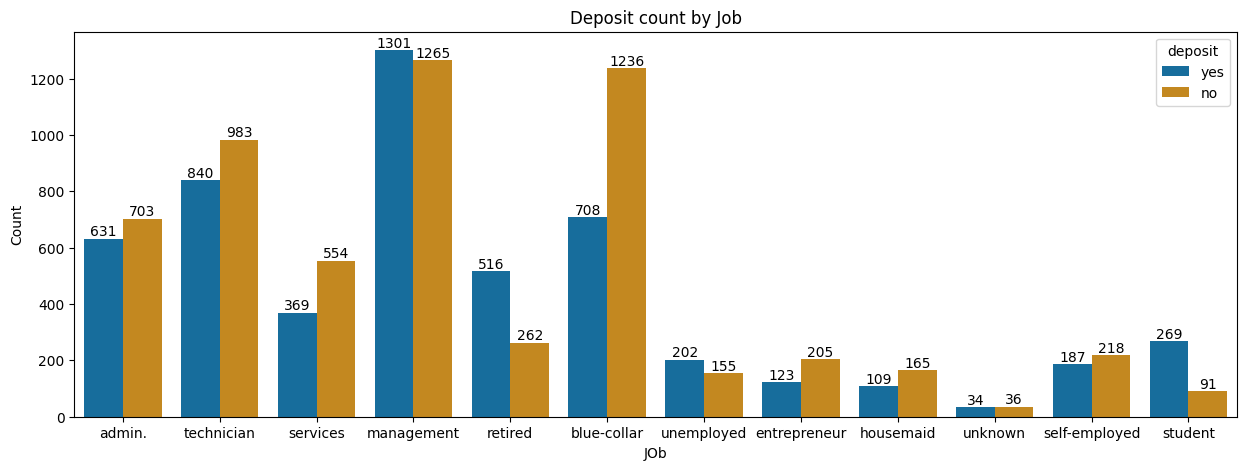

In [92]:
plt.figure(figsize=(15,5))
ax=sns.countplot(x=df['job'],hue=df['deposit'],palette='colorblind')
plt.title('Deposit count by Job')
plt.xlabel('JOb')
plt.ylabel('Count')
for container in ax.containers:
  ax.bar_label(container,fmt='%d',label_type='edge')
plt.show()

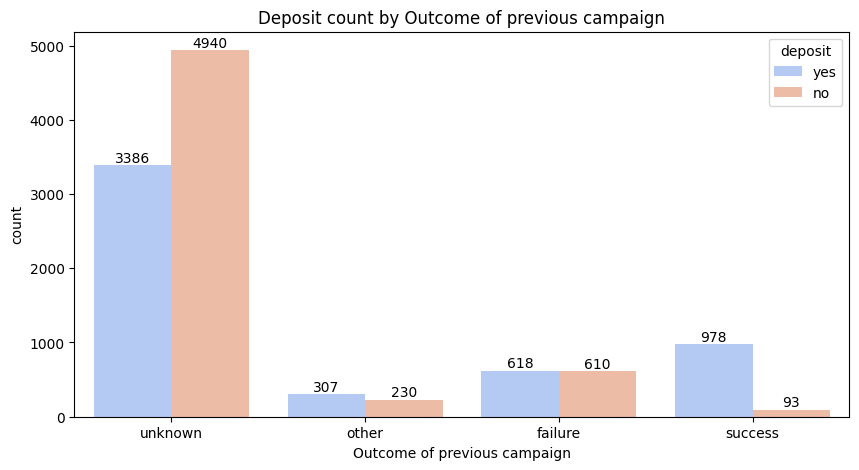

In [93]:
plt.figure(figsize=(10,5))
ax=sns.countplot(x=df['poutcome'],hue=df['deposit'],palette="coolwarm")
plt.title('Deposit count by Outcome of previous campaign')
plt.xlabel('Outcome of previous campaign')
plt.ylabel('count')
for container in ax.containers:
  ax.bar_label(container,fmt="%d",label_type='edge')
plt.show()

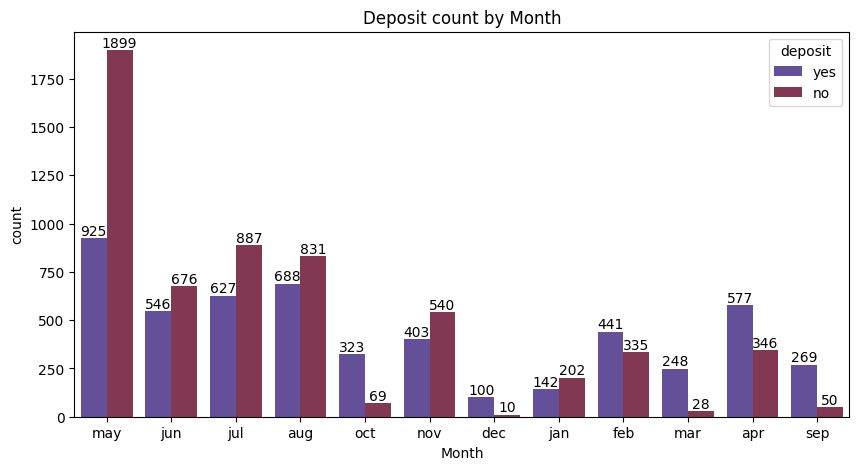

In [94]:
plt.figure(figsize=(10,5))
ax=sns.countplot(x=df['month'],hue=df['deposit'],palette="twilight")
plt.title('Deposit count by Month')
plt.xlabel('Month')
plt.ylabel('count')
for container in ax.containers:
  ax.bar_label(container,fmt="%d",label_type='edge')
plt.show()

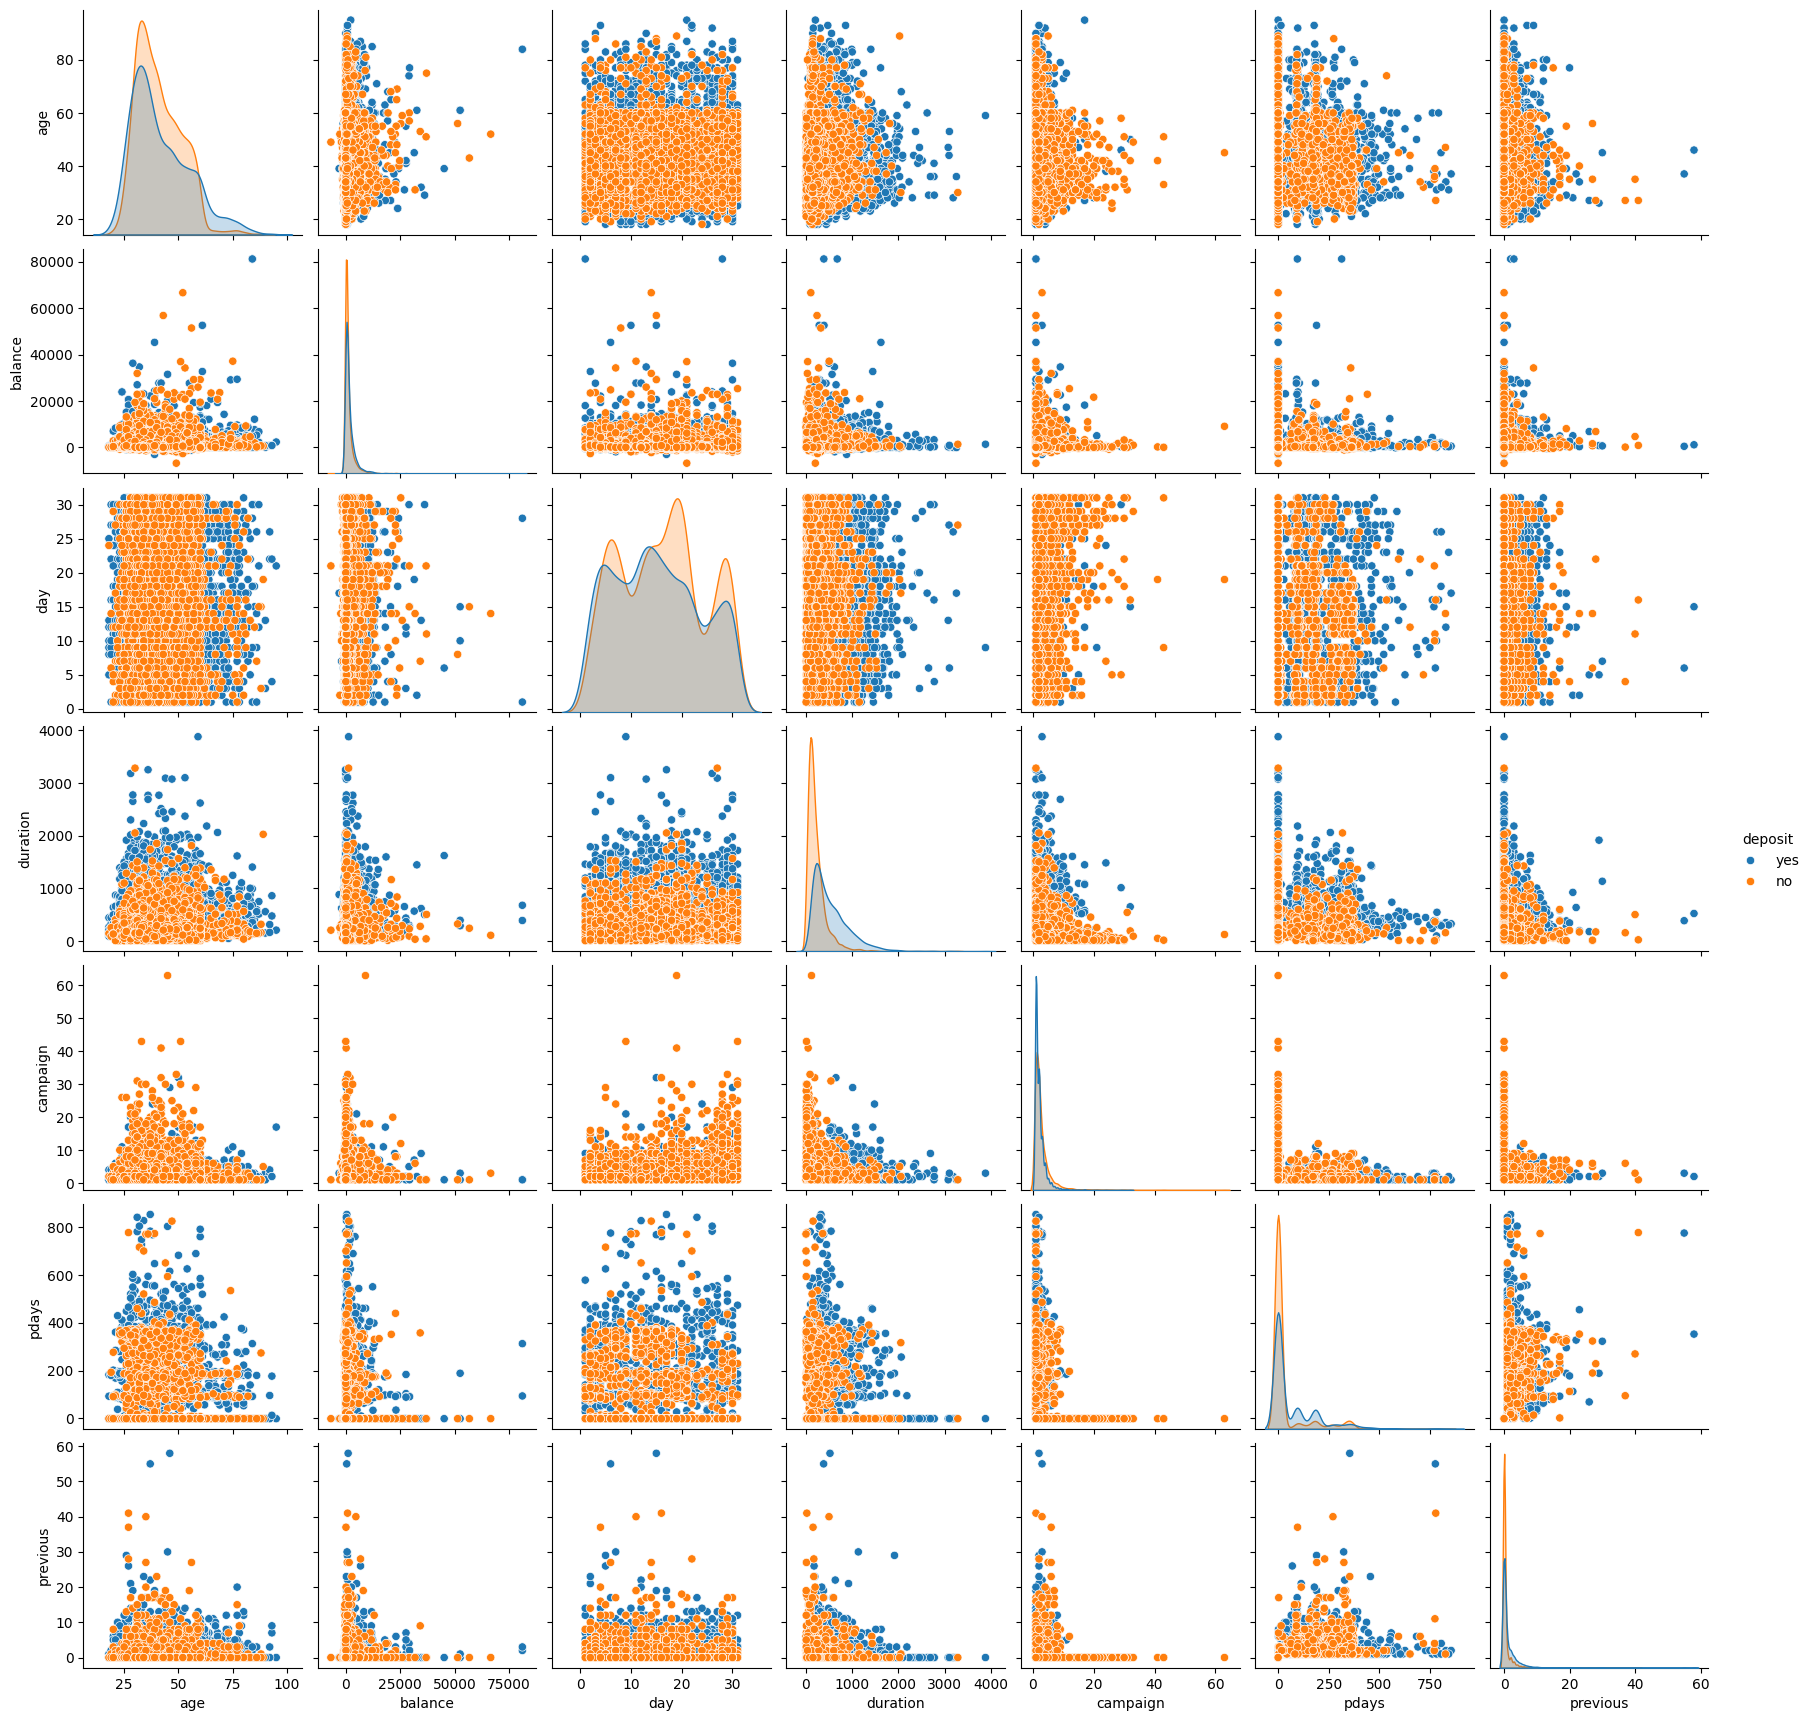

In [95]:
sns.pairplot(df,hue = 'deposit')
plt.show()